In [4]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch
import torch.nn as nn
import numpy as np 
import os
import matplotlib.pyplot as plt

from core.models.vae import VAE_model, VAE_loss
from core.dataset import FilteredMNIST
from core.utils import extract_representation, plot_latent_space, plot_input_space
from core.models.rbf_variance import RBF_Variance

# Download and preprocess data

In [5]:
# MNIST Dataset transformation
mnist_transform = transforms.Compose([
    transforms.ToTensor(), # Converts to [0, 1] interval
    transforms.Lambda(lambda x: torch.flatten(x)) # Flattens the image to a 1D vector
])

# Download and load the MNIST dataset
full_train_dataset = datasets.MNIST(root='mnist_data', train=True, transform=mnist_transform, download=True)
print("Original size of the dataset: ", len(full_train_dataset))
filtered_labels = [0, 1]

print("Filtered labels: ", filtered_labels)
train_dataset = FilteredMNIST(full_train_dataset, filtered_labels)
print("New size of the dataset: ", len(train_dataset))

batch_size = 256
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True,num_workers=4)

Original size of the dataset:  60000
Filtered labels:  [0, 1]
New size of the dataset:  12665


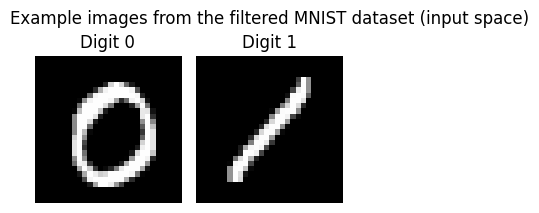

In [6]:
plot_input_space(train_loader, filtered_labels)

# Load VAE

In [7]:
# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Construct an artificial dataset
D = 28 * 28  # Dimensionality of the input

# Parameters of the VAE
d = 2  # The latent space dimension
activFun = nn.LeakyReLU(0.2)
H = 128
lambda_reg = 1e-7  # For the weights of the networks
epochs = 500
learning_rate = 1e-4
clipping_value = 1
batch_size = 128
r_max = 1  # au lieu de 1.0
warmup = int(0.5 * epochs)

In [8]:
# The model and the optimizer for the VAE
model = VAE_model(d, D, H, activFun).to(device)
optimizer_model = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=lambda_reg)

# Train VAE

[Epoch 0/500] total: 745.2 | recon: 707.5 | kl: 0.883 | r: 0.00
[Epoch 10/500] total: -683.3 | recon: -715.2 | kl: 133.508 | r: 0.04
[Epoch 20/500] total: -763.7 | recon: -894.4 | kl: 265.164 | r: 0.08
[Epoch 30/500] total: -791.0 | recon: -855.2 | kl: 197.027 | r: 0.12
[Epoch 40/500] total: -825.9 | recon: -768.2 | kl: 96.507 | r: 0.16
[Epoch 50/500] total: -911.3 | recon: -911.2 | kl: 58.271 | r: 0.20
[Epoch 60/500] total: -943.6 | recon: -981.8 | kl: 44.950 | r: 0.24
[Epoch 70/500] total: -958.5 | recon: -942.4 | kl: 31.375 | r: 0.28
[Epoch 80/500] total: -969.1 | recon: -1005.7 | kl: 34.055 | r: 0.32
[Epoch 90/500] total: -975.7 | recon: -997.7 | kl: 27.501 | r: 0.36
[Epoch 100/500] total: -981.2 | recon: -1002.7 | kl: 23.340 | r: 0.40
[Epoch 110/500] total: -986.1 | recon: -986.0 | kl: 20.507 | r: 0.44
[Epoch 120/500] total: -990.9 | recon: -979.0 | kl: 16.960 | r: 0.48
[Epoch 130/500] total: -996.3 | recon: -1020.0 | kl: 17.598 | r: 0.52
[Epoch 140/500] total: -1001.7 | recon: -1

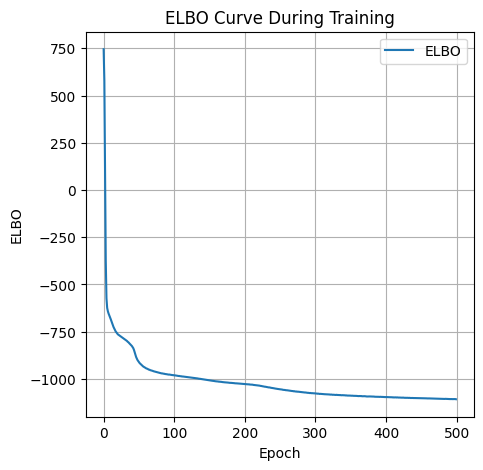

In [15]:
X_train_list = []

for X, _ in train_loader:
    X_train_list.append(X)

X_train = torch.cat(X_train_list).cpu()

# Train the VAE with the new prior
ELBO = np.zeros((epochs, 1))

# Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_model,
    mode='min',
    factor=0.5,
    patience=20,
    verbose=True
)

for epoch in range(epochs):

    model.train()

    train_loss = 0
    train_loss_num = 0

    # Warmup annealing (epoch-level)
    r = min(r_max, epoch / warmup * r_max)

    for X_batch, _ in train_loader:

        X_batch = X_batch.to(device)

        mu_x, log_var_x, z_rep, mu_z, log_var_z = model(X_batch)

        loss, recon, kl = VAE_loss(
            x=X_batch,
            mu_x=mu_x,
            log_var_x=log_var_x,
            mu_z=mu_z,
            log_var_z=log_var_z,
            r=r
        )

        optimizer_model.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            clipping_value
        )

        optimizer_model.step()

        train_loss += loss.item()
        train_loss_num += 1

    epoch_loss = train_loss / max(train_loss_num, 1)
    ELBO[epoch] = epoch_loss

    scheduler.step(epoch_loss)

    if epoch % 10 == 0:
        print(f"[Epoch {epoch}/{epochs}] total: {epoch_loss:.1f} | recon: {recon:.1f} | kl: {kl:.3f} | r: {r:.2f}")

print("Training finished")

# Plot the ELBO curve
plt.figure(figsize=(5, 5))
plt.plot(ELBO, label='ELBO')
plt.xlabel('Epoch')
plt.ylabel('ELBO')
plt.title('ELBO Curve During Training')
plt.legend()
plt.grid()
plt.show()

In [16]:
# Save model
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, "vae_model_mnist_01_withvar.pt")

torch.save(model.state_dict(), model_path)

print(f"Model saved in {model_path}")

Model saved in saved_models/vae_model_mnist_01_withvar.pt


# Sanity checks: latent space

In [6]:
# if model already exists, load it
model_path = "saved_models/vae_model_mnist_016_withvar.pt"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print(f"Model loaded from {model_path}")

Model loaded from saved_models/vae_model_mnist_016_withvar.pt


In [7]:
# Extract the latent representations for the training data
Z, labels, X_train = extract_representation(model, train_loader, device)

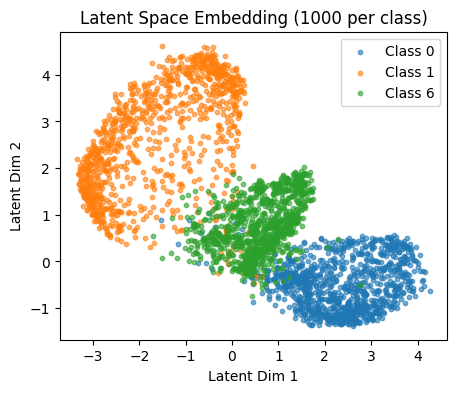

In [8]:
plot_latent_space(Z, labels)

In [9]:
# if model already exists, load it
model_path = "saved_models/vae_model_mnist_01_withvar.pt"
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path))
    print(f"Model loaded from {model_path}")

Model loaded from saved_models/vae_model_mnist_01_withvar.pt


In [10]:
# Extract the latent representations for the training data
Z, labels, X_train = extract_representation(model, train_loader, device)

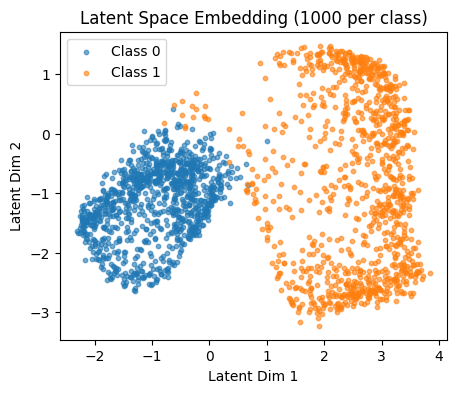

In [11]:
plot_latent_space(Z, labels)

# RBF Training

RBF centers initialized
[RBF Epoch 0/5000] loss: 912.102
[RBF Epoch 100/5000] loss: 675.882
[RBF Epoch 200/5000] loss: 508.210
[RBF Epoch 300/5000] loss: 389.461
[RBF Epoch 400/5000] loss: 302.347
[RBF Epoch 500/5000] loss: 235.326
[RBF Epoch 600/5000] loss: 181.420
[RBF Epoch 700/5000] loss: 136.475
[RBF Epoch 800/5000] loss: 97.943
[RBF Epoch 900/5000] loss: 64.190
[RBF Epoch 1000/5000] loss: 34.118
[RBF Epoch 1100/5000] loss: 6.962
[RBF Epoch 1200/5000] loss: -17.830
[RBF Epoch 1300/5000] loss: -40.670
[RBF Epoch 1400/5000] loss: -61.870
[RBF Epoch 1500/5000] loss: -81.675
[RBF Epoch 1600/5000] loss: -100.278
[RBF Epoch 1700/5000] loss: -117.836
[RBF Epoch 1800/5000] loss: -134.475
[RBF Epoch 1900/5000] loss: -150.301
[RBF Epoch 2000/5000] loss: -165.402
[RBF Epoch 2100/5000] loss: -179.854
[RBF Epoch 2200/5000] loss: -193.720
[RBF Epoch 2300/5000] loss: -207.054
[RBF Epoch 2400/5000] loss: -219.904
[RBF Epoch 2500/5000] loss: -232.311
[RBF Epoch 2600/5000] loss: -244.311
[RBF Epoch

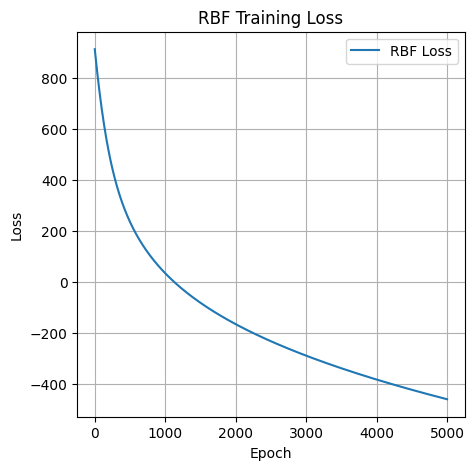

In [51]:
# Create and initialize the RBF layer
K = 15  # Number of RBF centers
rbf = RBF_Variance(d=d, D=D, K=K, zeta=1e-6).to(device)
rbf.init_centers(Z, a=1.25)

# Train the RBF layer
optimizer_rbf = torch.optim.Adam(rbf.parameters(), lr=1e-2)

rbf.train()
model.eval()

Z_train = Z.to(device)
X_train = X_train.to(device)

losses = []
epochs=5000

for epoch in range(epochs):
    # Fixed reconstruction mean from VAE
    with torch.no_grad():
        mu_x = model.decode(Z_train)[0]  # (N, D)

    # RBF variance
    log_var = rbf(Z_train)              # (N, D)
    log_var = torch.clamp(log_var, -10, 10)

    # Gaussian log-likelihood
    recon_loss = 0.5 * (
        log_var + ((X_train - mu_x) ** 2) / log_var.exp()
    ).sum(dim=1).mean()

    optimizer_rbf.zero_grad()
    recon_loss.backward()
    optimizer_rbf.step()

    losses.append(recon_loss.item())

    if epoch % 100 == 0:
        print(f"[RBF Epoch {epoch}/{epochs}] loss: {recon_loss.item():.3f}")

# Plot RBF training loss
plt.figure(figsize=(5, 5))
plt.plot(losses, label='RBF Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RBF Training Loss')
plt.legend()
plt.grid()
plt.show()


In [56]:
# Save
torch.save(rbf.state_dict(), 'saved_models/rbf_variance_01.pt')